# 03 - Modelos y comparación

Se entrenan y comparan varios modelos para seleccionar aquel con mejor capacidad de **ordenar las transacciones según su riesgo de fraude**, evaluada mediante **PR-AUC** sobre el conjunto de validación.
PR-AUC resulta especialmente informativo en este problema debido al desbalance de clases (~5% de fraude), ya que resume el compromiso entre precision y recall a lo largo de distintos umbrales de decisión. Al ser una métrica de ranking independiente de un umbral operativo específico, permite comparar los modelos antes de realizar la calibración y seleccionar el umbral económico que maximiza la ganancia (notebook 04).

Contenido:

- **Baseline lineal**: regresión logística con `class_weight="balanced"`.
- **Gradient boosting**: XGBoost y LightGBM, cada uno afinado con Optuna.
- **Bagging**: Random Forest, como contraste de familia.
- **SVM (kernel RBF) y red neuronal (MLP)**
- **Piso de ruido**: cada modelo se reentrena con varias semillas para saber si
  las diferencias son reales o solo azar del muestreo.
- **Comparación** por PR-AUC (curvas PR y ROC).


In [1]:
import sys
sys.path.append("..")
%load_ext autoreload
%autoreload 2

from src.data import load_raw, clean
from src.features import temporal_split, build_preprocessor, NUM_FEATURES, CAT_LOW, CAT_HIGH
from src.model import build_logistic, build_xgb, build_lgbm, build_rf
from sklearn.metrics import (precision_recall_curve, roc_curve,
                             average_precision_score, roc_auc_score)
import matplotlib.pyplot as plt
import numpy as np

import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time



# Recargar, limpiar y partir
df = clean(load_raw("../data/dataset.csv"))
train, val, test = temporal_split(df, train_frac=0.7, val_frac=0.15)
RANDOM_STATE = 42

FEATURES = NUM_FEATURES + CAT_LOW + CAT_HIGH
X_train, y_train = train[FEATURES], train["fraude"]
X_val,   y_val   = val[FEATURES],   val["fraude"]

# Peso para compensar el desbalance (lo usan XGBoost y Optuna)
spw = (y_train == 0).sum() / (y_train == 1).sum()

## Regresión Logística

Modelo lineal, interpretable, que sirve de linea base. Su pipeline incluye:

- **`StandardScaler`**: la regresión logística es sensible a la escala de las variables,
  así que se estandarizan (media 0, desvío 1).
- **`class_weight="balanced"`**: maneja el desbalance dándole más peso a la
  clase minoritaria (fraude), inversamente a su frecuencia. Sin esto, el modelo
  tendería a ignorar los fraudes.
- **`max_iter=1000`**: asegura que el optimizador tenga iteraciones suficientes
  para converger.

In [2]:
# Entrenar el baseline
logistic = build_logistic()
logistic.fit(X_train, y_train)

# Primer chequeo con PR-AUC en validación
p_val = logistic.predict_proba(X_val)[:, 1]
print("PR-AUC (val):", round(average_precision_score(y_val, p_val), 4))

PR-AUC (val): 0.3158


## XGBoost

Captura no linealidades e interacciones que la regresión logística no puede. No
lleva escalado (los árboles son invariantes a la escala). Hiperparámetros:

- **`scale_pos_weight=18.3`**: maneja el desbalance (negativos/positivos ≈ 95/5).
  Es el equivalente al `class_weight` de la regresión logística.
- **`n_estimators=400`** y **`learning_rate=0.05`**: cuántos árboles y cuánto
  aporta cada uno. Van de la mano: learning rate bajo pide más árboles, y da un
  aprendizaje más gradual y robusto.
- **`max_depth=6`**: profundidad de cada árbol; controla la complejidad y el
  riesgo de sobreajuste.
- **`subsample=0.8`** y **`colsample_bytree=0.8`**: cada árbol usa el 80% de las
  filas y el 80% de las columnas. Ese azar reduce el sobreajuste.
- **`eval_metric="aucpr"`**: la métrica que XGBoost monitorea internamente
  (PR-AUC, coherente con la métrica de comparación).

In [3]:
xgb = build_xgb(scale_pos_weight=spw)
xgb.fit(X_train, y_train)

p_val_xgb = xgb.predict_proba(X_val)[:, 1]
print("PR-AUC XGBoost (val):", round(average_precision_score(y_val, p_val_xgb), 4))

PR-AUC XGBoost (val): 0.43


## XGBoost optimizado con Optuna

Se afinan los hiperparámetros de XGBoost con **Optuna**, que busca la combinación que maximiza el PR-AUC en
validación. Para acelerar, se preprocesa una sola vez (fit en train, transform
en val) y cada prueba solo reentrena el clasificador. La búsqueda se centra en
los hiperparámetros que más influyen: los que controlan el aprendizaje
(`n_estimators`, `learning_rate`), la complejidad de los árboles (`max_depth`,
`min_child_weight`, `gamma`) y la regularización estocástica (`subsample`,
`colsample_bytree`).

In [4]:
optuna.logging.set_verbosity(optuna.logging.WARNING)  # menos ruido en la salida

# Preprocesar una sola vez (fit en train) 
pre = build_preprocessor()
X_train_p = pre.fit_transform(X_train, y_train)
X_val_p   = pre.transform(X_val)

def objetivo(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
    }
    clf = XGBClassifier(**params, scale_pos_weight=spw, eval_metric="aucpr",
                        random_state=RANDOM_STATE, n_jobs=1)
    clf.fit(X_train_p, y_train)
    p = clf.predict_proba(X_val_p)[:, 1]
    return average_precision_score(y_val, p)

estudio = optuna.create_study(direction="maximize",
                              sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudio.optimize(objetivo, n_trials=30, show_progress_bar=True)

print("Mejor PR-AUC (val):", round(estudio.best_value, 4))
print("Mejores hiperparámetros:", estudio.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Mejor PR-AUC (val): 0.4428
Mejores hiperparámetros: {'n_estimators': 664, 'learning_rate': 0.0286642261344634, 'max_depth': 4, 'subsample': 0.6756782218133349, 'colsample_bytree': 0.7922339615553947, 'min_child_weight': 5, 'gamma': 2.601477385704998, 'reg_lambda': 4.524540905246321}


**Resultado del tuning**: Optuna mejora el PR-AUC en validación de 0,43 (base) a **0,44** . La
mejora es modesta: el modelo base ya captura la mayor parte de la señal.

Los mejores hiperparámetros describen un modelo **más regularizado**: árboles
más superficiales (`max_depth=4` vs 6), más restrictivos (`min_child_weight=6`,
`gamma=2.75`) y más árboles con learning rate más bajo. Sugiere que el modelo
generaliza mejor con menos complejidad por árbol.

El PR-AUC en val es optimista (Optuna optimizó sobre val); la evaluación honesta
es en test (notebook 04), comparando la ganancia del modelo base vs. optimizado.

## Lightgbm

LightGBM es otro algoritmo de *gradient boosting* sobre árboles, de la misma
familia que XGBoost. Se incluye como comparación para verificar que la elección
de XGBoost es robusta dentro de esa familia. Al ser de árboles, tampoco necesita
escalado, y maneja el desbalance con `scale_pos_weight`.

La diferencia técnica clave con XGBoost es **cómo hace crecer los árboles**:
XGBoost crece por niveles (*level-wise*, todos los nodos de un nivel antes de
bajar), mientras que LightGBM crece por hoja (*leaf-wise*, divide siempre la
hoja que más reduce el error). 

In [5]:
lgbm = build_lgbm(scale_pos_weight=spw)
lgbm.fit(X_train, y_train)

p_val_lgbm = lgbm.predict_proba(X_val)[:, 1]
print("PR-AUC LightGBM (val):", round(average_precision_score(y_val, p_val_lgbm), 4))

PR-AUC LightGBM (val): 0.4341


## Lightgbm optimizado 

In [6]:
def objetivo_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "feature_fraction":  trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
    }
    clf = LGBMClassifier(**params, bagging_freq=1, scale_pos_weight=spw,
                         random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    clf.fit(X_train_p, y_train)
    p = clf.predict_proba(X_val_p)[:, 1]
    return average_precision_score(y_val, p)

estudio_lgbm = optuna.create_study(direction="maximize",
                                   sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudio_lgbm.optimize(objetivo_lgbm, n_trials=30, show_progress_bar=True)

print("Mejor PR-AUC LightGBM (val):", round(estudio_lgbm.best_value, 4))
print("Mejores hiperparámetros:", estudio_lgbm.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Mejor PR-AUC LightGBM (val): 0.4397
Mejores hiperparámetros: {'n_estimators': 621, 'learning_rate': 0.029494148336943186, 'num_leaves': 16, 'max_depth': 12, 'min_child_samples': 23, 'feature_fraction': 0.7826173426603851, 'bagging_fraction': 0.8099926423362572, 'reg_lambda': 0.10243918246367029}


Tras optimizar con Optuna, LightGBM alcanza PR-AUC ~0,439 en validación,
prácticamente idéntico al XGBoost optimizado (~0,440). Los dos gradient boosting
quedan empatados, lo que confirma que la elección del modelo es robusta dentro
de la familia. Se mantiene XGBoost como modelo final por estar marginalmente
adelante y por estar ya integrado en el pipeline de calibración y evaluación.

## SVM

In [7]:
""""
# SVM RBF sobre el entrenamiento COMPLETO (105k). Puede tardar varios minutos.
svm_full = Pipeline([
    ("pre", build_preprocessor()),
    ("sc",  StandardScaler(with_mean=False)),
    ("clf", SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE)),
])
t0 = time.time()
svm_full.fit(X_train, y_train)
t_fit = time.time() - t0

t1 = time.time()
scores_svm_full = svm_full.decision_function(X_val)
t_pred = time.time() - t1

print(f"SVM RBF (105k filas) → PR-AUC: {average_precision_score(y_val, scores_svm_full):.4f}")
print(f"  entrenamiento: {t_fit:.1f}s | predicción sobre 22.5k val: {t_pred:.1f}s")
"""

'"\n# SVM RBF sobre el entrenamiento COMPLETO (105k). Puede tardar varios minutos.\nsvm_full = Pipeline([\n    ("pre", build_preprocessor()),\n    ("sc",  StandardScaler(with_mean=False)),\n    ("clf", SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE)),\n])\nt0 = time.time()\nsvm_full.fit(X_train, y_train)\nt_fit = time.time() - t0\n\nt1 = time.time()\nscores_svm_full = svm_full.decision_function(X_val)\nt_pred = time.time() - t1\n\nprint(f"SVM RBF (105k filas) → PR-AUC: {average_precision_score(y_val, scores_svm_full):.4f}")\nprint(f"  entrenamiento: {t_fit:.1f}s | predicción sobre 22.5k val: {t_pred:.1f}s")\n'

SVM toma mucho más tiempo en entrenamiento y sus resultados son peores: 

SVM RBF (105k filas) → PR-AUC: 0.3001
  entrenamiento: 344.6s | predicción sobre 22.5k val: 61.0s
  
se deja comentado para que no se demore tanto la ejecución del notebook

## Redes (MLP)

In [8]:
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("pre", build_preprocessor()),
    ("sc",  StandardScaler(with_mean=False)),
    ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200,
                          early_stopping=True, random_state=RANDOM_STATE)),
])
t0 = time.time()
mlp.fit(X_train, y_train)
p_mlp = mlp.predict_proba(X_val)[:, 1]
print(f"MLP (64,32) → PR-AUC: {average_precision_score(y_val, p_mlp):.4f} "
      f"| entrenó en {time.time()-t0:.1f}s")

MLP (64,32) → PR-AUC: 0.4173 | entrenó en 7.7s


## Ruido de los modelos

In [9]:
SEMILLAS = [0, 1, 2, 3, 4]

# steps[-1][1] es el clasificador (último paso del pipeline), sin importar su nombre
def con_semilla(construir, s):
    m = construir()
    m.steps[-1][1].set_params(random_state=s)
    return m

constructores = {
    "XGBoost (opt)":  lambda: build_xgb(scale_pos_weight=spw, params=estudio.best_params),
    "LightGBM (opt)": lambda: build_lgbm(scale_pos_weight=spw, params=estudio_lgbm.best_params),
    "Random Forest":  lambda: build_rf(),
    "MLP (64,32)":    lambda: Pipeline([
        ("pre", build_preprocessor()),
        ("sc",  StandardScaler(with_mean=False)),
        ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200,
                              early_stopping=True, random_state=RANDOM_STATE)),
    ]),
}

resumen = {}
for nombre, construir in constructores.items():
    scores = []
    for s in SEMILLAS:
        m = con_semilla(construir, s)
        m.fit(X_train, y_train)
        p = m.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, p))
    scores = np.array(scores)
    resumen[nombre] = scores
    print(f"{nombre:16} PR-AUC: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"(min {scores.min():.4f}, max {scores.max():.4f})")

# Veredicto sobre los dos mejores
ruido = np.mean([s.std() for s in resumen.values()])
medias = {k: float(v.mean()) for k, v in resumen.items()}
orden = sorted(medias, key=medias.get, reverse=True)
sep = medias[orden[0]] - medias[orden[1]]
print(f"\nMejores dos: {orden[0]} ({medias[orden[0]]:.4f}) vs "
      f"{orden[1]} ({medias[orden[1]]:.4f})")
print(f"Separación entre ellos: {sep:.4f}")
print(f"Piso de ruido (desvío típico): {ruido:.4f}")
print("→", "EMPATADOS: la diferencia está dentro del ruido"
      if sep < ruido else "La diferencia supera el ruido")

XGBoost (opt)    PR-AUC: 0.4394 ± 0.0010  (min 0.4379, max 0.4409)
LightGBM (opt)   PR-AUC: 0.4404 ± 0.0019  (min 0.4375, max 0.4434)
Random Forest    PR-AUC: 0.4178 ± 0.0022  (min 0.4146, max 0.4208)
MLP (64,32)      PR-AUC: 0.4232 ± 0.0040  (min 0.4185, max 0.4294)

Mejores dos: LightGBM (opt) (0.4404) vs XGBoost (opt) (0.4394)
Separación entre ellos: 0.0010
Piso de ruido (desvío típico): 0.0023
→ EMPATADOS: la diferencia está dentro del ruido


Los modelos con aleatoriedad interna se reentrenaron con 5 semillas para medir
el **piso de ruido**: la variación del PR-AUC atribuible solo al azar del
muestreo, no a una diferencia real de calidad.

| Modelo | PR-AUC (val) | Desvío |
|--------|--------------|--------|
| LightGBM (opt) | 0,4404 | ±0,0019 |
| XGBoost (opt)  | 0,4394 | ±0,0010 |
| MLP (64, 32)   | 0,4232 | ±0,0040 |
| Random Forest  | 0,4178 | ±0,0022 |

Piso de ruido (desvío típico): **0,0023**.

**1. XGBoost y LightGBM están empatados.** Su diferencia (0,0010) es menor que
el piso de ruido (0,0023): reportar "LightGBM > XGBoost" sería confundir azar
con señal. 
**2. La ventaja del gradient boosting.** Frente a Random Forest
(bagging) y a la red (MLP), la brecha es de ~0,017–0,022, es decir 7–9× el piso
de ruido: muy por encima del azar. La elección de la *familia* de modelos está
justificada por los datos; la elección *dentro* de la familia es indiferente.

## Comparación Final

In [10]:
modelos = {
    "Regresión logística":   build_logistic(),
    "XGBoost (optimizado)":  build_xgb(scale_pos_weight=spw, params=estudio.best_params),
    "LightGBM (optimizado)": build_lgbm(scale_pos_weight=spw, params=estudio_lgbm.best_params),
    "Random Forest":         build_rf(),
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    p = modelo.predict_proba(X_val)[:, 1]
    resultados[nombre] = average_precision_score(y_val, p)
    print(f"{nombre:24} PR-AUC (val): {resultados[nombre]:.4f}")

Regresión logística      PR-AUC (val): 0.3158
XGBoost (optimizado)     PR-AUC (val): 0.4428
LightGBM (optimizado)    PR-AUC (val): 0.4397
Random Forest            PR-AUC (val): 0.4163


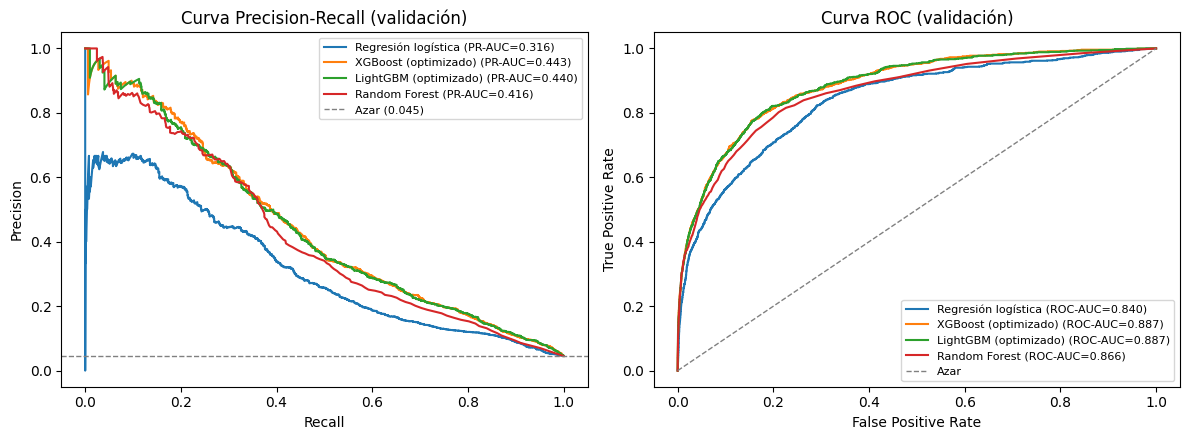

In [11]:
fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=(12, 4.5))

for nombre, modelo in modelos.items():
    p = modelo.predict_proba(X_val)[:, 1]      # evaluamos en validación
    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_val, p)
    ap = average_precision_score(y_val, p)
    ax_pr.plot(rec, prec, label=f"{nombre} (PR-AUC={ap:.3f})")
    # ROC
    fpr, tpr, _ = roc_curve(y_val, p)
    auc = roc_auc_score(y_val, p)
    ax_roc.plot(fpr, tpr, label=f"{nombre} (ROC-AUC={auc:.3f})")

ax_pr.axhline(y_val.mean(), ls="--", color="gray", lw=1,
              label=f"Azar ({y_val.mean():.3f})")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Curva Precision-Recall (validación)"); ax_pr.legend(fontsize=8)

ax_roc.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, label="Azar")
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("Curva ROC (validación)"); ax_roc.legend(fontsize=8)

plt.tight_layout()
plt.show()

- Contraste PR vs. ROC: en ROC los tres modelos se ven cercanos y altos
  (0,84–0,89), pero en PR la logística queda claramente por debajo. Ilustra por
  qué la ROC-AUC es optimista con desbalance y la PR-AUC es más honesta.